# RNACentral ID Mapping — Presence Check

Check which RNAChallenge transcript IDs (resolved + unresolved) appear in the
[RNACentral ID mapping file](https://ftp.ebi.ac.uk/pub/databases/RNAcentral/current_release/id_mapping/id_mapping.tsv.gz).

**Input files** (`paper/rnachallenge_genes/results/`):
- `classified_ids.tsv` — all IDs classified by the pipeline
- `ncbi_ucsc_unresolved.tsv`, `external_unresolved.tsv`, `gramene_unresolved.tsv`,  
  `biomart_unresolved.tsv`, `ncbi_genbank_unresolved.tsv`, `unknown_ids.tsv` — IDs not yet resolved

**Output files** (`paper/rnachallenge_genes/results/`):
- `rnacentral_resolved.tsv` — IDs found in RNACentral mapping
- `rnacentral_unresolved.tsv` — IDs not found in RNACentral mapping
- `rnacentral_mapping_cache.tsv.gz` — local cache of the full mapping (skip re-download)


## 1. Import Required Libraries

In [1]:
from __future__ import annotations

import gzip
import random
import urllib.request
from pathlib import Path

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ── Reproducibility ───────────────────────────────────────────────────────────
np.random.seed(42)
random.seed(42)

# ── Font setup (Arial via msfonts) ────────────────────────────────────────────
_font_dir = Path("/mnt/cbib/LNClassifier/msfonts")
if _font_dir.is_dir():
    for _f in _font_dir.glob("*.ttf"):
        fm.fontManager.addfont(str(_f))
    plt.rcParams["font.family"] = "Arial"

plt.rcParams.update({"figure.dpi": 150, "axes.spines.top": False, "axes.spines.right": False})

# ── Paths ─────────────────────────────────────────────────────────────────────
PIPELINE_DIR   = Path("/mnt/cbib/LNClassifier/paper/rnachallenge_genes")
RESULTS        = PIPELINE_DIR / "results"
MAPPING_CACHE  = RESULTS / "rnacentral_mapping_cache.tsv.gz"
MAPPING_URL    = (
    "https://ftp.ebi.ac.uk/pub/databases/RNAcentral/current_release/"
    "id_mapping/id_mapping.tsv.gz"
)

print(f"Pipeline dir : {PIPELINE_DIR}")
print(f"Results dir  : {RESULTS}")
print(f"Mapping cache: {MAPPING_CACHE}")


Pipeline dir : /mnt/cbib/LNClassifier/paper/rnachallenge_genes
Results dir  : /mnt/cbib/LNClassifier/paper/rnachallenge_genes/results
Mapping cache: /mnt/cbib/LNClassifier/paper/rnachallenge_genes/results/rnacentral_mapping_cache.tsv.gz


## 2. Download and Cache the RNACentral ID Mapping File

The file is ~3 GB compressed. On first run it is downloaded to
`results/rnacentral_mapping_cache.tsv.gz`; subsequent runs reuse the cache.

Columns (no header in the source file):
`urs_id | db_name | external_id | taxid | rna_type | gene_name`

In [2]:
MAPPING_COLS = ["urs_id", "db_name", "external_id", "taxid", "rna_type", "gene_name"]


def download_mapping(url: str, dest: Path) -> None:
    """Stream-download *url* to *dest* with a progress indicator."""
    print(f"Downloading {url}")
    print(f"  → {dest}")
    dest.parent.mkdir(parents=True, exist_ok=True)

    with urllib.request.urlopen(url) as response:
        total = int(response.headers.get("Content-Length", 0))
        downloaded = 0
        chunk = 1 << 20  # 1 MiB
        with open(dest, "wb") as fh:
            while True:
                buf = response.read(chunk)
                if not buf:
                    break
                fh.write(buf)
                downloaded += len(buf)
                if total:
                    pct = downloaded / total * 100
                    print(f"\r  {downloaded / 1e9:.2f} GB / {total / 1e9:.2f} GB  ({pct:.1f}%)",
                          end="", flush=True)
    print(f"\nDone — saved to {dest}")


if not MAPPING_CACHE.exists():
    download_mapping(MAPPING_URL, MAPPING_CACHE)
else:
    size_gb = MAPPING_CACHE.stat().st_size / 1e9
    print(f"Cache already present: {MAPPING_CACHE} ({size_gb:.2f} GB) — skipping download.")


Cache already present: /mnt/cbib/LNClassifier/paper/rnachallenge_genes/results/rnacentral_mapping_cache.tsv.gz (1.85 GB) — skipping download.


In [3]:
print("Loading RNACentral ID mapping into memory (this may take a minute)…")

mapping_df: pd.DataFrame = pd.read_csv(
    MAPPING_CACHE,
    sep="\t",
    header=None,
    names=MAPPING_COLS,
    compression="gzip",
    dtype={
        "urs_id": "string",
        "db_name": "string",
        "external_id": "string",
        "taxid": "Int64",
        "rna_type": "string",
        "gene_name": "string",
    },
    low_memory=False,
)

print(f"Loaded {len(mapping_df):,} entries from RNACentral mapping.")
mapping_df.head()


Loading RNACentral ID mapping into memory (this may take a minute)…


Loaded 185,344,236 entries from RNACentral mapping.


,urs_id,db_name,external_id,taxid,rna_type,gene_name
0,URS0000000001,ENA,GU786683.1:1..200:rRNA,77133,rRNA,<NA>
1,URS0000000001,ENA,GU786868.1:1..200:rRNA,77133,rRNA,<NA>
2,URS0000000001,ENA,GU786889.1:1..200:rRNA,77133,rRNA,<NA>
3,URS0000000001,ENA,GU790934.1:1..200:rRNA,77133,rRNA,<NA>
4,URS0000000001,ENA,GU792481.1:1..200:rRNA,77133,rRNA,<NA>


## 3. Inspect the ID Mapping Data

In [4]:
print("=== Schema ===")
print(mapping_df.dtypes)
print()
print("=== Sample rows ===")
display(mapping_df.sample(5, random_state=42))
print()
print(f"Total entries : {len(mapping_df):,}")
print(f"Unique URS IDs: {mapping_df['urs_id'].nunique():,}")
print(f"Unique ext IDs: {mapping_df['external_id'].nunique():,}")
print(f"Databases     : {mapping_df['db_name'].nunique()}")


=== Schema ===
urs_id         string[python]
db_name        string[python]
external_id    string[python]
taxid                   Int64
rna_type       string[python]
gene_name      string[python]
dtype: object

=== Sample rows ===


,urs_id,db_name,external_id,taxid,rna_type,gene_name
94548510,URS000052C32B,ENA,KC911472.1:7445..7516:tRNA,9606,tRNA,<NA>
30263484,URS000019EB0A,SILVA,SILVA:GQ071641.1:<1..>1340,77133,rRNA,<NA>
170739327,URS00026D0BDF,ENA,JAUXSJ010000186.1:12619..12701:tRNA,2052176,tRNA,<NA>
64443447,URS000038765D,ENA,JBHSSE010000013.1:673..745:tRNA,2559917,tRNA,<NA>
150112644,URS0001C12762,ENA,KDRO01101910.1:1..491:rRNA,77133,rRNA,<NA>



Total entries : 185,344,236
Unique URS IDs: 37,464,528
Unique ext IDs: 177,356,870
Databases     : 52


Top 20 databases in RNACentral mapping:
db_name
ENA                 157381082
SILVA                10778966
RFAM                  7415984
ENSEMBL               1953212
ENSEMBL_METAZOA       1363066
GREENGENES            1144866
PLNCDB                 968058
MGNIFY                 571136
GENECARDS              550370
TMRNA_WEB              422053
GTRNADB                411160
ENSEMBL_GENCODE        333138
LNCBOOK                323950
EXPRESSION_ATLAS       319209
NONCODE                236163
PIRBASE                219278
ENSEMBL_PLANTS         131947
REFSEQ                 131191
LNCIPEDIA              127798
RIBOCENTRE              89747


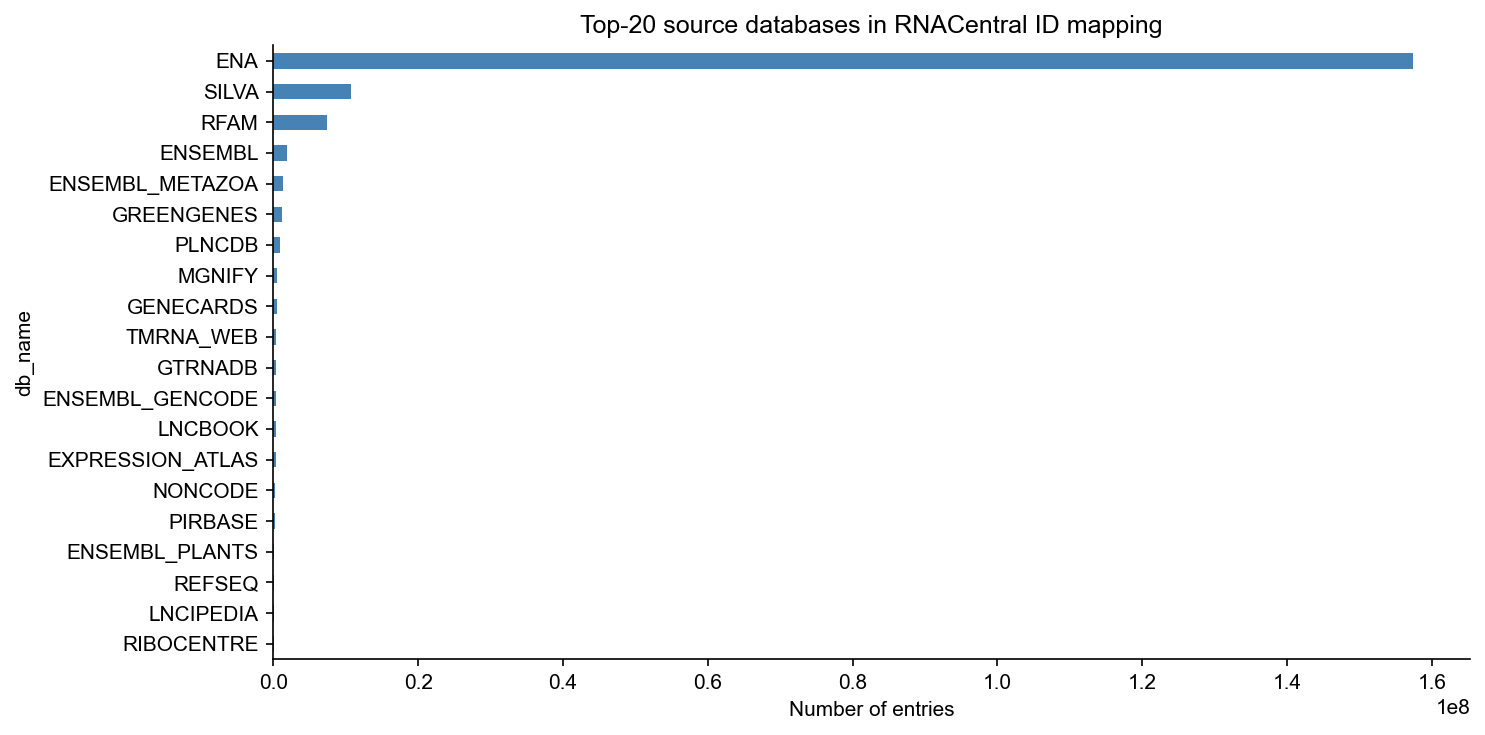

In [5]:
# Top-20 databases by entry count
db_counts: pd.Series = mapping_df["db_name"].value_counts()
print("Top 20 databases in RNACentral mapping:")
print(db_counts.head(20).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
db_counts.head(20).plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Number of entries")
ax.set_title("Top-20 source databases in RNACentral ID mapping")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(RESULTS / "rnacentral_db_distribution.pdf", bbox_inches="tight")
plt.savefig(RESULTS / "rnacentral_db_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


## 4. Load Query IDs

Collect **all** RNAChallenge transcript IDs — both resolved and unresolved — from the
pipeline result files.  We carry the originating file as a `source` tag so we can
break down hit rates per source later.

In [6]:
def _load_ids(filename: str, id_col: str = "transcript_id", source_label: str | None = None) -> pd.DataFrame:
    """Load *id_col* from *filename* in RESULTS; return a two-column DataFrame (transcript_id, source)."""
    path = RESULTS / filename
    if not path.exists():
        print(f"  [MISSING] {filename}")
        return pd.DataFrame(columns=["transcript_id", "source"])
    df = pd.read_csv(path, sep="\t", usecols=[id_col], dtype="string")
    df = df.rename(columns={id_col: "transcript_id"})
    df["source"] = source_label or filename
    n = len(df)
    print(f"  {filename:50s}  {n:6,} IDs")
    return df


print("Loading pipeline ID files…")
query_frames: list[pd.DataFrame] = [
    # All classified IDs (the full set across all sources)
    _load_ids("classified_ids.tsv",          source_label="classified"),
    # Unresolved buckets
    _load_ids("ncbi_ucsc_unresolved.tsv",    source_label="ncbi_ucsc_unresolved"),
    _load_ids("ncbi_genbank_unresolved.tsv", source_label="ncbi_genbank_unresolved"),
    _load_ids("external_unresolved.tsv",     source_label="external_unresolved"),
    _load_ids("gramene_unresolved.tsv",      source_label="gramene_unresolved"),
    _load_ids("biomart_unresolved.tsv",      source_label="biomart_unresolved"),
    # Completely unknown (pattern_unmatched etc.)
    _load_ids("unknown_ids.tsv",             source_label="unknown"),
]

query_all: pd.DataFrame = (
    pd.concat(query_frames, ignore_index=True)
    .dropna(subset=["transcript_id"])
    .drop_duplicates(subset=["transcript_id"])
    .reset_index(drop=True)
)

print(f"\nTotal unique query IDs: {len(query_all):,}")
query_all.head()


Loading pipeline ID files…
  classified_ids.tsv                                  21,491 IDs
  ncbi_ucsc_unresolved.tsv                             2,969 IDs
  ncbi_genbank_unresolved.tsv                          2,469 IDs
  external_unresolved.tsv                              2,204 IDs
  gramene_unresolved.tsv                               1,619 IDs
  biomart_unresolved.tsv                               1,739 IDs
  unknown_ids.tsv                                      5,767 IDs

Total unique query IDs: 27,258


,transcript_id,source
0,XM_020294737.1,classified
1,XM_020313512.1,classified
2,XM_020315385.1,classified
3,XM_020315948.1,classified
4,XM_020316852.1,classified


In [7]:
# Count per pipeline source before de-duplication (informational)
counts_by_source = (
    pd.concat(query_frames, ignore_index=True)
    .dropna(subset=["transcript_id"])
    .groupby("source")["transcript_id"]
    .count()
    .sort_values(ascending=False)
)
print("IDs per pipeline source (pre-dedup):")
print(counts_by_source.to_string())


IDs per pipeline source (pre-dedup):
source
classified                 21491
unknown                     5767
ncbi_ucsc_unresolved        2969
ncbi_genbank_unresolved     2469
external_unresolved         2204
biomart_unresolved          1739
gramene_unresolved          1619


## 5. Check ID Presence in RNACentral Mapping

Build a set of all `external_id` values from the mapping table and test membership.
We also perform an optional per-database refined lookup so we can see *which* database(s)
recognised each ID.

In [8]:
# Build a fast set of all external IDs in the mapping
print("Building external_id lookup set…")
rnacentral_ext_ids: frozenset[str] = frozenset(
    mapping_df["external_id"].dropna().astype(str)
)
print(f"  {len(rnacentral_ext_ids):,} unique external IDs in RNACentral mapping.")

# Some IDs include version suffixes (e.g., NM_001234.2 → NM_001234);
# we try both versioned and un-versioned matches.
def _strip_version(id_str: str) -> str:
    """Remove trailing .N version suffix."""
    return id_str.rsplit(".", 1)[0] if "." in id_str else id_str


query_ids: pd.Series = query_all["transcript_id"].astype(str)

in_rnacentral_exact   = query_ids.isin(rnacentral_ext_ids)
unversioned_ids       = query_ids.map(_strip_version)
in_rnacentral_unver   = unversioned_ids.isin(rnacentral_ext_ids) & ~in_rnacentral_exact

query_all["in_rnacentral"]       = in_rnacentral_exact | in_rnacentral_unver
query_all["match_type"]          = "not_found"
query_all.loc[in_rnacentral_exact, "match_type"] = "exact"
query_all.loc[in_rnacentral_unver, "match_type"] = "unversioned"

print(f"\nExact matches       : {in_rnacentral_exact.sum():,}")
print(f"Unversioned matches : {in_rnacentral_unver.sum():,}")
print(f"Not found           : {(~query_all['in_rnacentral']).sum():,}")


Building external_id lookup set…
  177,356,870 unique external IDs in RNACentral mapping.

Exact matches       : 369
Unversioned matches : 357
Not found           : 26,532


In [9]:
# For matched IDs: retrieve RNACentral metadata via a left-merge on exact external_id.
# We keep only the first hit per external_id (one RNACentral URS per query ID).
mapping_deduped: pd.DataFrame = (
    mapping_df[["external_id", "urs_id", "db_name", "rna_type", "taxid"]]
    .dropna(subset=["external_id"])
    .drop_duplicates(subset=["external_id"], keep="first")
)

resolved_df: pd.DataFrame = (
    query_all[query_all["in_rnacentral"]]
    .copy()
    .assign(external_id=lambda d: d.apply(
        lambda r: r["transcript_id"] if r["match_type"] == "exact"
                  else _strip_version(r["transcript_id"]),
        axis=1,
    ))
    .merge(mapping_deduped, on="external_id", how="left")
    .drop(columns=["external_id"])
)

unresolved_df: pd.DataFrame = query_all[~query_all["in_rnacentral"]].copy()

print(f"Resolved   DataFrame : {len(resolved_df):,} rows")
print(f"Unresolved DataFrame : {len(unresolved_df):,} rows")
resolved_df.head()


Resolved   DataFrame : 726 rows
Unresolved DataFrame : 26,532 rows


,transcript_id,source,in_rnacentral,match_type,urs_id,db_name,rna_type,taxid
0,ENST00000576232.1,classified,True,unversioned,URS00025F25A1,ENSEMBL,lncRNA,9606
1,ENST00000570344.1,classified,True,unversioned,URS0002A6B04F,ENSEMBL,lncRNA,9606
2,ENST00000518821.1,classified,True,unversioned,URS00007C4FBC,ENSEMBL,lncRNA,9606
3,ENST00000437367.2,classified,True,unversioned,URS0002A4C35C,ENSEMBL,lncRNA,9606
4,ENST00000518600.1,classified,True,unversioned,URS0002A6CBD6,ENSEMBL,lncRNA,9606


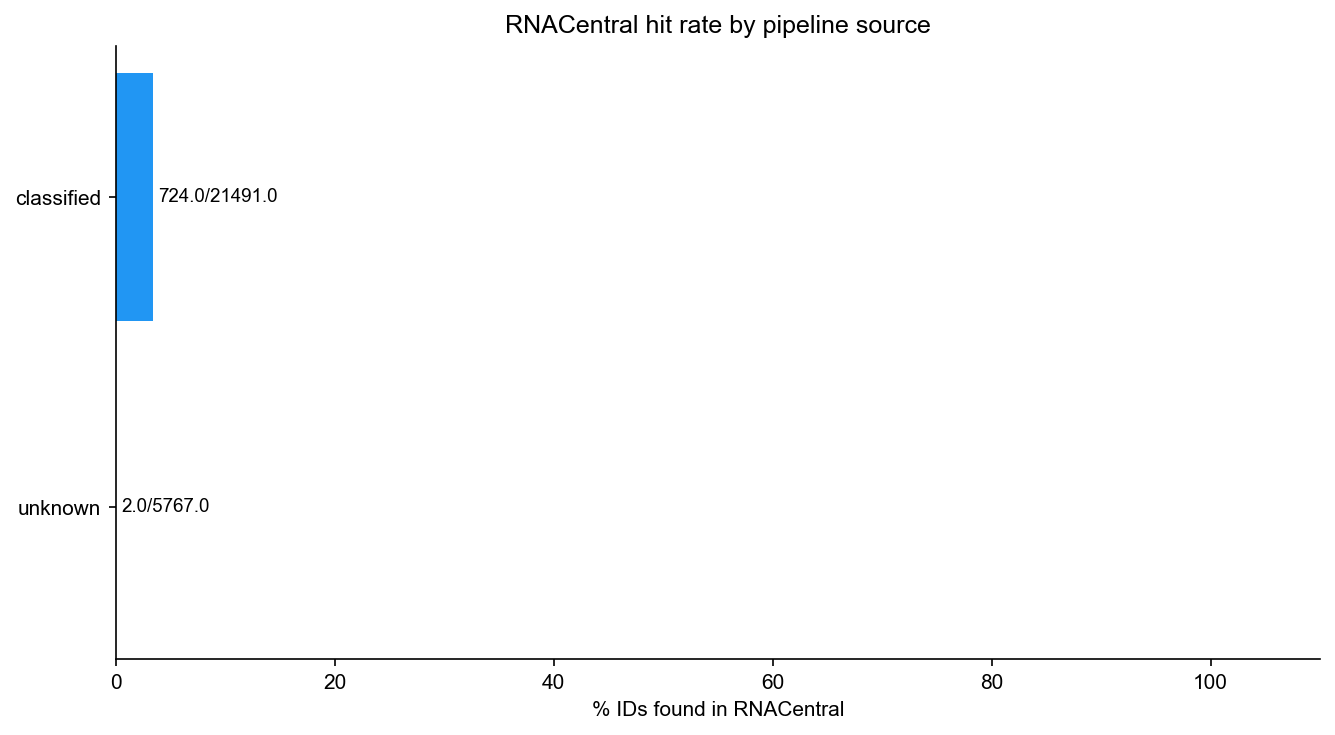

            total  found       pct
source                            
unknown      5767      2  0.034680
classified  21491    724  3.368852


In [10]:
# -- Hit rate by pipeline source --
source_stats: pd.DataFrame = (
    query_all.groupby("source")["in_rnacentral"]
    .agg(total="count", found="sum")
    .assign(pct=lambda d: d["found"] / d["total"] * 100)
    .sort_values("pct", ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#2196F3" if p > 0 else "#BDBDBD" for p in source_stats["pct"]]
ax.barh(source_stats.index, source_stats["pct"], color=colors)
ax.set_xlabel("% IDs found in RNACentral")
ax.set_title("RNACentral hit rate by pipeline source")
for i, (idx, row) in enumerate(source_stats.iterrows()):
    ax.text(row["pct"] + 0.5, i, f'{row["found"]}/{row["total"]}', va="center", fontsize=9)
ax.set_xlim(0, 110)
plt.tight_layout()
plt.savefig(RESULTS / "rnacentral_hit_rate.pdf", bbox_inches="tight")
plt.savefig(RESULTS / "rnacentral_hit_rate.png", dpi=300, bbox_inches="tight")
plt.show()
print(source_stats.to_string())


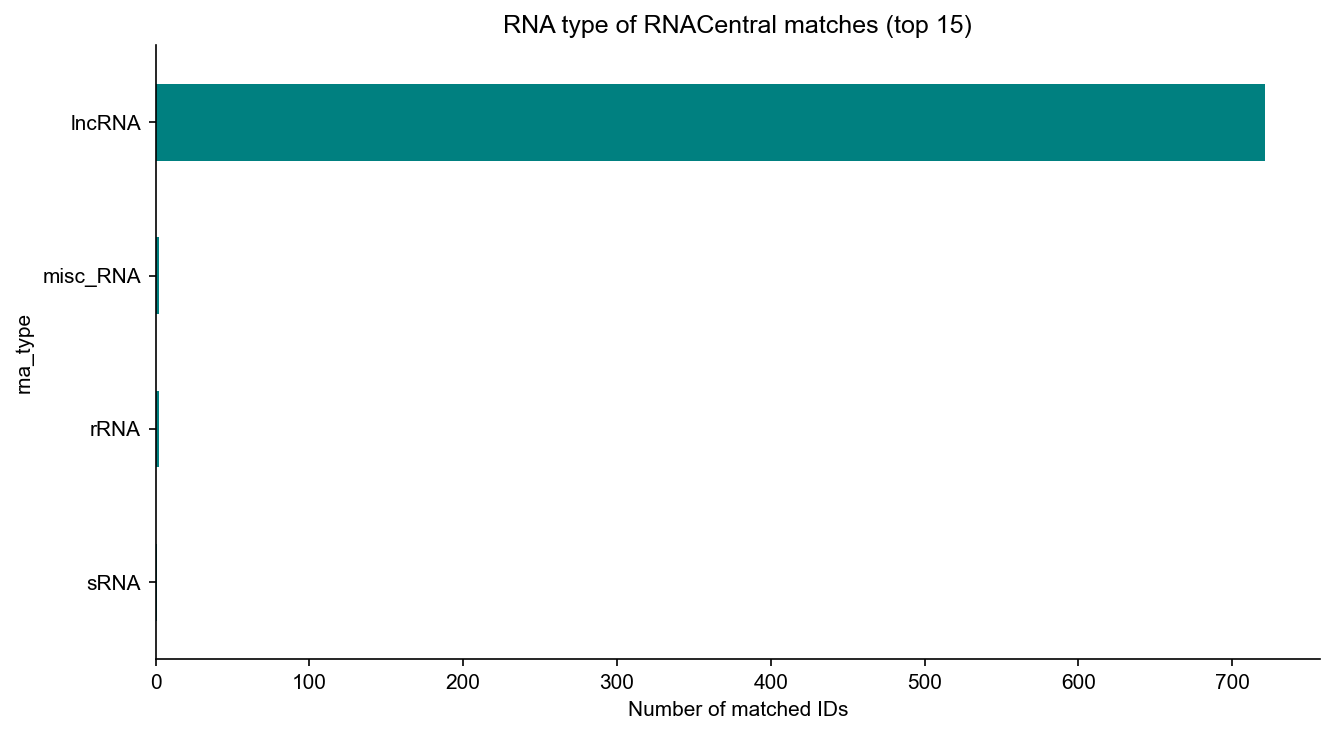

In [11]:
# -- RNA type distribution among hits --
if len(resolved_df) > 0 and "rna_type" in resolved_df.columns:
    rna_type_counts = resolved_df["rna_type"].value_counts().head(15)

    fig, ax = plt.subplots(figsize=(9, 5))
    rna_type_counts.plot(kind="barh", ax=ax, color="teal")
    ax.set_xlabel("Number of matched IDs")
    ax.set_title("RNA type of RNACentral matches (top 15)")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(RESULTS / "rnacentral_rna_type_dist.pdf", bbox_inches="tight")
    plt.savefig(RESULTS / "rnacentral_rna_type_dist.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("No matched IDs or rna_type column unavailable.")


## 6. Summarise and Export Results

In [12]:
total_queried  = len(query_all)
total_found    = int(query_all["in_rnacentral"].sum())
total_not_found = total_queried - total_found
match_rate     = total_found / total_queried * 100 if total_queried else 0.0

print("=" * 50)
print("  RNACentral ID Lookup Summary")
print("=" * 50)
print(f"  Total query IDs   : {total_queried:>8,}")
print(f"  Found (exact)     : {int(in_rnacentral_exact.sum()):>8,}")
print(f"  Found (unver.)    : {int(in_rnacentral_unver.sum()):>8,}")
print(f"  Total found       : {total_found:>8,}  ({match_rate:.1f}%)")
print(f"  Not found         : {total_not_found:>8,}  ({100 - match_rate:.1f}%)")
print("=" * 50)

# -- Export --
out_resolved   = RESULTS / "rnacentral_resolved.tsv"
out_unresolved = RESULTS / "rnacentral_unresolved.tsv"

resolved_df.to_csv(out_resolved,   sep="\t", index=False)
unresolved_df.to_csv(out_unresolved, sep="\t", index=False)

print(f"\nSaved: {out_resolved}")
print(f"Saved: {out_unresolved}")


  RNACentral ID Lookup Summary
  Total query IDs   :   27,258
  Found (exact)     :      369
  Found (unver.)    :      357
  Total found       :      726  (2.7%)
  Not found         :   26,532  (97.3%)

Saved: /mnt/cbib/LNClassifier/paper/rnachallenge_genes/results/rnacentral_resolved.tsv
Saved: /mnt/cbib/LNClassifier/paper/rnachallenge_genes/results/rnacentral_unresolved.tsv


## Summary / Conclusions

Output files written to `paper/rnachallenge_genes/results/`:

| File | Description |
|------|-------------|
| `rnacentral_resolved.tsv` | Query IDs found in RNACentral, with URS ID, database, and RNA type |
| `rnacentral_unresolved.tsv` | Query IDs not found in RNACentral |
| `rnacentral_db_distribution.{pdf,png}` | Top-20 databases in the mapping |
| `rnacentral_hit_rate.{pdf,png}` | Hit rate per pipeline source |
| `rnacentral_rna_type_dist.{pdf,png}` | RNA type distribution of hits |
| `rnacentral_mapping_cache.tsv.gz` | Local cache of `id_mapping.tsv.gz` |

> **Note:** `match_type` in `rnacentral_resolved.tsv` is `"exact"` when the original
> versioned ID matched directly, or `"unversioned"` when only the accession root
> (without `.N` suffix) matched.
